In [1]:
from pandas import read_csv
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import shapely.wkt
import geopandas as gpd
import contextily as cx

import warnings
warnings.filterwarnings('ignore')

path = '/Users/xiaodanxu/Library/CloudStorage/GoogleDrive-arielinseu@gmail.com/My Drive/HEI/emission_rates/agg_emission_rate_generator'
os.chdir(path)

In [8]:
# define scenario variable
region = 'MTC'
year = '2018'

# load final output
er_file = 'PL_' + region + '_' + year + '_Annual_emission_rate_agg.csv'
er_dir = os.path.join('Input', er_file)
emfac_emission_rate = read_csv(er_dir)
emfac_emission_rate.columns

Index(['calendar_year', 'season_month', 'sub_area', 'vehicle_class', 'fuel',
       'temperature', 'relative_humidity', 'process', 'speed_time',
       'pollutant', 'emission_rate'],
      dtype='object')

In [9]:
# select activities and filter by areas
unique_areas = emfac_emission_rate.sub_area.unique()
print(unique_areas)

inv_dir = 'CA_EMFAC_inventory_' + year
inv_path = os.path.join('Input', inv_dir)
all_files = os.listdir(inv_path)

activity_inv = []

# Loop through the CSV files and read each one into a dataframe
for file in all_files:
    # Check if the CSV file contains the string "vmt"
    if "vmt" in file:
        # Read the CSV file into a dataframe
        inv_data = read_csv(os.path.join(inv_path, file))
        # Append the dataframe to the list
        activity_inv.append(inv_data)

# Merge the dataframes into a single dataframe
activity_inv_df = pd.concat(activity_inv)

# select data within study area
activity_inv_df = \
activity_inv_df.loc[activity_inv_df['sub_area'].isin(unique_areas)]
print(activity_inv_df.sub_area.unique())

activity_inv_df.head(5)

['Sonoma (NC)' 'Solano (SV)' 'Alameda (SF)' 'Contra Costa (SF)'
 'Marin (SF)' 'Napa (SF)' 'San Francisco (SF)' 'San Mateo (SF)'
 'Santa Clara (SF)' 'Solano (SF)' 'Sonoma (SF)']
['Sonoma (NC)' 'Solano (SV)' 'Alameda (SF)' 'Contra Costa (SF)'
 'Napa (SF)' 'Marin (SF)' 'San Mateo (SF)' 'San Francisco (SF)'
 'Solano (SF)' 'Santa Clara (SF)' 'Sonoma (SF)']


,calendar_year,sub_area,vehicle_class,fuel,total_vmt,cvmt,evmt
1338,2018,Sonoma (NC),All Other Buses,Dsl,687.571694,687.571694,0.000000
1339,2018,Sonoma (NC),LDA,Dsl,9952.192520,9952.192520,0.000000
1340,2018,Sonoma (NC),LDA,Elec,18705.275903,0.000000,18705.275903
1341,2018,Sonoma (NC),LDA,Gas,884725.260806,884725.260806,0.000000
1342,2018,Sonoma (NC),LDA,Phe,10873.747257,5892.175172,4981.572085


In [10]:
vehicle_classes = activity_inv_df.vehicle_class.unique()
# print(vehicle_classes)
LDV_and_buses = ['LDA', 'LDT1', 'LDT2', 'MDV', 'UBUS']
print(len(activity_inv_df))

ldv_and_bus_inv_df = \
activity_inv_df.loc[activity_inv_df['vehicle_class'].isin(LDV_and_buses)]

print(len(ldv_and_bus_inv_df))

ldv_and_bus_inv_df.head(5)

1013
204


,calendar_year,sub_area,vehicle_class,fuel,total_vmt,cvmt,evmt
1339,2018,Sonoma (NC),LDA,Dsl,9952.192520,9952.192520,0.000000
1340,2018,Sonoma (NC),LDA,Elec,18705.275903,0.000000,18705.275903
1341,2018,Sonoma (NC),LDA,Gas,884725.260806,884725.260806,0.000000
1342,2018,Sonoma (NC),LDA,Phe,10873.747257,5892.175172,4981.572085
1343,2018,Sonoma (NC),LDT1,Dsl,97.664713,97.664713,0.000000


In [11]:
# get fraction of EVs
grouping_var = ['calendar_year', 'sub_area', 'vehicle_class']
ldv_and_bus_inv_df.loc[:, 'fraction'] = \
ldv_and_bus_inv_df.loc[:, 'total_vmt'] / \
ldv_and_bus_inv_df.groupby(grouping_var)['total_vmt'].transform('sum')

ldv_and_bus_inv_df.loc[ldv_and_bus_inv_df['sub_area'] == 'Sonoma (NC)']


,calendar_year,sub_area,vehicle_class,fuel,total_vmt,cvmt,evmt,fraction
1339,2018,Sonoma (NC),LDA,Dsl,9952.192520,9952.192520,0.000000,0.010768
1340,2018,Sonoma (NC),LDA,Elec,18705.275903,0.000000,18705.275903,0.020238
1341,2018,Sonoma (NC),LDA,Gas,884725.260806,884725.260806,0.000000,0.957229
1342,2018,Sonoma (NC),LDA,Phe,10873.747257,5892.175172,4981.572085,0.011765
1343,2018,Sonoma (NC),LDT1,Dsl,97.664713,97.664713,0.000000,0.000676
1344,2018,Sonoma (NC),LDT1,Elec,96.936969,0.000000,96.936969,0.000671
1345,2018,Sonoma (NC),LDT1,Gas,144341.382634,144341.382634,0.000000,0.998636
1346,2018,Sonoma (NC),LDT1,Phe,2.513720,1.362114,1.151606,0.000017
1347,2018,Sonoma (NC),LDT2,Dsl,2864.109023,2864.109023,0.000000,0.006451
1348,2018,Sonoma (NC),LDT2,Elec,6.544050,0.000000,6.544050,0.000015


In [12]:
# sns.set(font_scale=1.4)  # crazy big
# sns.catplot(ldv_and_bus_inv_df, 
#             x="vehicle_class", y="fraction", 
#             hue="fuel", col = 'sub_area',
#             col_wrap = 4, kind = 'bar')
# # plt.title('VMT fraction by fuel in ' + year)
# plt.savefig('Plot/EMFAC_fuel_mix_by_veh_type_' + year + '.png',
#            dpi = 300, bbox_inches = 'tight')

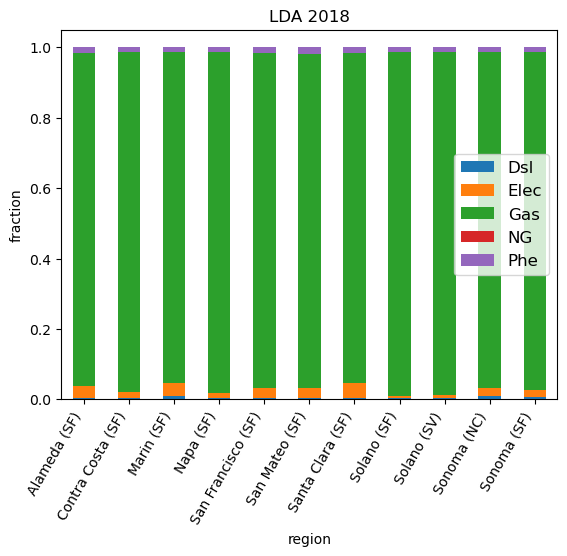

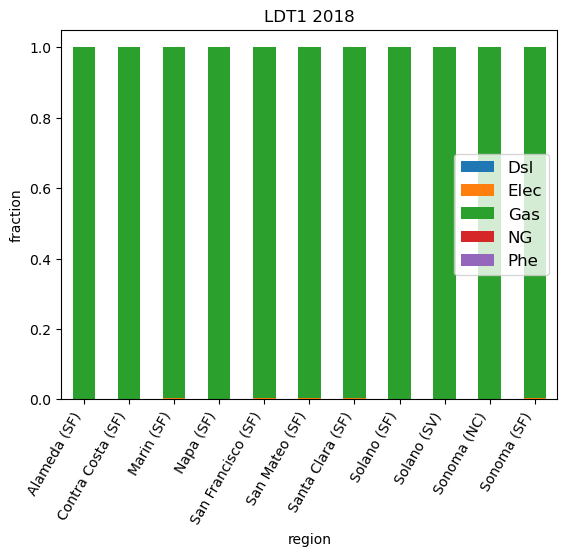

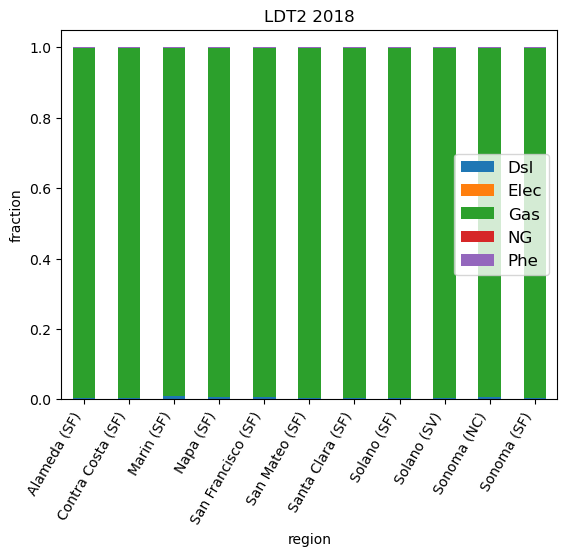

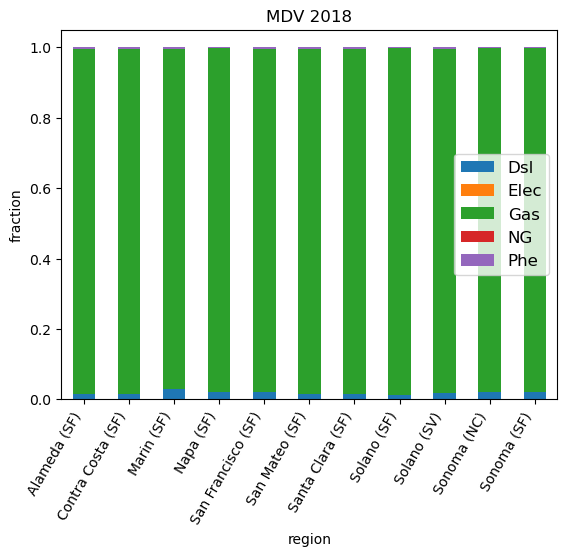

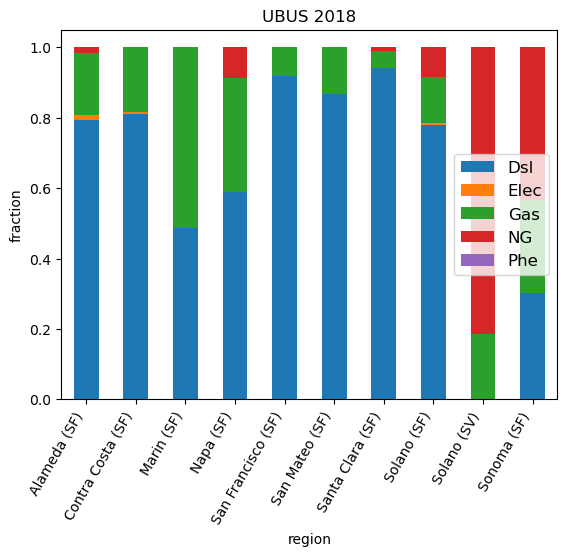

,calendar_year,sub_area,vehicle_class,Dsl,Elec,Gas,NG,Phe,total_vmt
0,2018,Alameda (SF),LDA,0.004207,0.033222,0.947907,NaN,0.014664,2.190605e+07
1,2018,Alameda (SF),LDT1,0.000605,0.001520,0.997852,NaN,0.000023,2.041510e+06
2,2018,Alameda (SF),LDT2,0.003739,0.000099,0.995667,NaN,0.000495,8.225418e+06
3,2018,Alameda (SF),MDV,0.014013,0.000053,0.982544,NaN,0.003391,4.560227e+06
4,2018,Alameda (SF),UBUS,0.794138,0.013507,0.175191,0.017164,NaN,1.069723e+05


In [13]:
ldv_and_bus_by_veh = \
pd.pivot_table(ldv_and_bus_inv_df,
               values = 'fraction',
               index = grouping_var,
               columns = 'fuel',
               aggfunc = 'sum')


# ldv_and_bus_by_veh.plot.bar(stacked = True)
ldv_and_bus_by_veh = ldv_and_bus_by_veh.reset_index()
ldv_and_bus_total_vmt = \
ldv_and_bus_inv_df.groupby(grouping_var)[['total_vmt']].sum()
ldv_and_bus_total_vmt = ldv_and_bus_total_vmt.reset_index()
ldv_and_bus_by_veh = pd.merge(ldv_and_bus_by_veh,
                              ldv_and_bus_total_vmt,
                              on = grouping_var,
                              how = 'left')

for veh in LDV_and_buses:
    ldv_and_bus_to_plot = \
    ldv_and_bus_by_veh.loc[ldv_and_bus_by_veh['vehicle_class'] == veh]
    ldv_and_bus_to_plot = \
    ldv_and_bus_to_plot.drop(columns = ['total_vmt', 'calendar_year'])
    ldv_and_bus_to_plot = ldv_and_bus_to_plot.set_index('sub_area')
    ldv_and_bus_to_plot.plot.bar(stacked = True)
    plt.xticks(rotation = 60, ha = 'right')
    plt.xlabel('region')
    plt.ylabel('fraction')
    plt.title(veh + ' ' + year)
    plt.legend(loc = 'center right', fontsize = 12)
    plt.savefig('Plot/EMFAC_' + region + '_' + year + '_fuel_mix_for_' + veh + '.png',
               dpi = 300, bbox_inches = 'tight')

    plt.show()
ldv_and_bus_by_veh.head(5)

In [14]:
ldv_and_bus_by_veh = ldv_and_bus_by_veh.fillna(0)
output_file = 'EMFAC_' + region + '_' + year + '_LDV_BUS_fuel_mix.csv'
ldv_and_bus_by_veh.to_csv(os.path.join('Output', output_file))